In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# ==========================================
# 1. Parameter settings
# ==========================================
# Logistic map band-merging point parameter
U_CRITICAL = 1.543689012692076 

# Sample-size settings
# Note: block entropy is data-hungry; we generate plenty of samples for statistical significance
PRIME_LIMIT = 5_000_000  # Prime upper limit
LOGISTIC_STEPS = 500_000 # Logistic iteration steps
MAX_BLOCK_SIZE = 12      # Maximum block length (k)

# ==========================================
# 2. Data generation and renormalization
# ==========================================
def get_normalized_prime_symbols(limit):
    """
    Generate prime gaps, then renormalize by local density and symbolize.
    Rule: Gap / ln(p) > 1  -> '1' (large gap),  otherwise '0' (small gap)
    """
    print(f"1. Generating primes (Limit={limit})...")
    # Sieve of Eratosthenes
    sieve = np.ones(limit // 2, dtype=bool)
    for i in range(3, int(limit**0.5) + 1, 2):
        if sieve[i // 2]:
            sieve[i*i // 2 :: i] = False
    primes = np.array([1] + [2 * i + 1 for i in range(1, limit // 2) if sieve[i]])
    
    # Compute gaps
    gaps = np.diff(primes)
    # Position of each gap (use the starting prime)
    p_vals = primes[:-1]
    
    # --- Key step: renormalization ---
    # Remove the 1/ln(n) trend so the sequence becomes stationary
    # Avoid ln(2) being zero/too small; start from index 1 (prime 3)
    valid_idx = p_vals > 2
    normalized_gaps = gaps[valid_idx] / np.log(p_vals[valid_idx])
    
    # --- Symbolization ---
    # Convert continuous values to a 0/1 symbol sequence
    # 1 = "larger than average gap" (escape), 0 = "smaller than average gap" (stay)
    symbols = (normalized_gaps > 1.0).astype(int)
    return symbols

def get_logistic_symbols(n_steps, u):
    """
    Generate gaps from the Logistic map and symbolize them.
    """
    print(f"2. Generating Logistic orbit (u={u})...")
    x = 0.1
    gaps = []
    current_gap = 0
    
    # Warm-up
    for _ in range(10000):
        x = 1 - u * x * x
        
    # Iterate
    for _ in range(n_steps):
        x = 1 - u * x * x
        if x < 0: # "prime"-like event occurs
            if current_gap > 0:
                gaps.append(current_gap)
            current_gap = 1
        else:
            current_gap += 1
            
    gaps = np.array(gaps)
    
    # Normalization (Logistic system is stationary; divide by global mean)
    norm_gaps = gaps / np.mean(gaps)
    
    # Symbolize
    symbols = (norm_gaps > 1.0).astype(int)
    return symbols

# ==========================================
# 3. Block-entropy calculation
# ==========================================
def calc_block_entropy(sequence, max_k):
    """
    Compute block entropy H(k) and entropy rate h(k) for various k.
    H(k) = - sum p(w) log2 p(w)
    h(k) = H(k+1) - H(k)
    """
    print("3. Computing block entropy...")
    n = len(sequence)
    entropies = []  # H(k)
    
    for k in range(1, max_k + 2):
        # Sliding-window frequency counts
        # Convert to tuple for dict keys (faster than strings)
        # Plain list comprehension; replace with scipy/pandas for very large data
        if n < k:
            break
            
        # Extract all subsequences of length k
        # Simple but memory-heavy; optimize for production
        blocks = [tuple(sequence[i:i+k]) for i in range(n - k + 1)]
        counts = Counter(blocks)
        total = len(blocks)
        
        H_k = 0
        for count in counts.values():
            p = count / total
            H_k -= p * math.log2(p)
        entropies.append(H_k)
        
    # Entropy rate h(k) = H(k+1) - H(k)
    entropy_rates = []
    for i in range(len(entropies) - 1):
        h_k = entropies[i+1] - entropies[i]
        entropy_rates.append(h_k)
        
    return entropies[:-1], entropy_rates

# ==========================================
# 4. Main program and visualization
# ==========================================
def main():
    # A. Obtain symbolic sequences
    prime_sym = get_normalized_prime_symbols(PRIME_LIMIT)
    log_sym = get_logistic_symbols(LOGISTIC_STEPS, U_CRITICAL)
    
    print(f"Prime sequence length: {len(prime_sym)}")
    print(f"Logistic sequence length: {len(log_sym)}")
    
    # Trim to equal lengths for a fair comparison
    min_len = min(len(prime_sym), len(log_sym))
    prime_sym = prime_sym[:min_len]
    log_sym = log_sym[:min_len]
    
    # B. Compute entropy
    H_prime, h_prime = calc_block_entropy(prime_sym, MAX_BLOCK_SIZE)
    H_log, h_log = calc_block_entropy(log_sym, MAX_BLOCK_SIZE)
    
    ks = np.arange(1, MAX_BLOCK_SIZE + 1)
    
    # C. Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: block entropy H(k)
    ax1.plot(ks, H_prime, 'b-o', label='Primes (Renormalized)')
    ax1.plot(ks, H_log, 'r-s', label=f'Logistic (u={U_CRITICAL:.4f})')
    # Reference line: fully random sequence gives H(k) = k (H(1)=1 bit)
    ax1.plot(ks, ks, 'k--', alpha=0.3, label='Pure Random (H=k)')
    
    ax1.set_title('Block Entropy H(k)')
    ax1.set_xlabel('Block Size k')
    ax1.set_ylabel('Entropy (bits)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: entropy rate h(k) (source-entropy estimate)
    ax2.plot(ks, h_prime, 'b-o', label='Primes Entropy Rate')
    ax2.plot(ks, h_log, 'r-s', label='Logistic Entropy Rate')
    
    # Theoretical reference value ln(2)/2 ~ 0.346 bits? 
    # Note: whether the paper-quoted ln(2)/2 uses natural log or base-2 log needs verification.
    # Information theory usually uses base 2. ln(2)/2 (nats) = 0.5 (bits) if h = ln(2)/2 * 1/ln(2) = 0.5?
    # Or simply the numeric value 0.346. We draw 0.5 as a reference since fully random gives 1.0.
    ax2.axhline(y=0.5, color='g', linestyle='--', alpha=0.5, label='0.5 bits (Half Random?)')
    
    ax2.set_title('Entropy Rate h(k) = H(k+1) - H(k)')
    ax2.set_xlabel('Block Size k')
    ax2.set_ylabel('Entropy Rate (bits/symbol)')
    ax2.set_ylim(0, 1.1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("1. Inspect the slope of H(k); overlapping curves mean the same information density.")
    print("2. Inspect h(k) convergence; as k grows it approaches the true Kolmogorov-Sinai (KS) entropy.")
    print("   - h(k) -> 1 indicates fully random noise.")
    print("   - h(k) -> 0 indicates a periodic system.")
    print("   - h(k) stabilising between 0 and 1 (e.g. 0.4-0.6) is strong evidence both are deterministic chaotic systems.")
    print("3. If the red (Logistic) and blue (Prime) curves track closely, that is strong evidence of identical dynamical complexity.")

1. 生成素数 (Limit=5000000)...
2. 生成 Logistic 轨道 (u=1.543689012692076)...
素数序列长度: 348511
Logistic序列长度: 110152
3. 计算块熵...
3. 计算块熵...


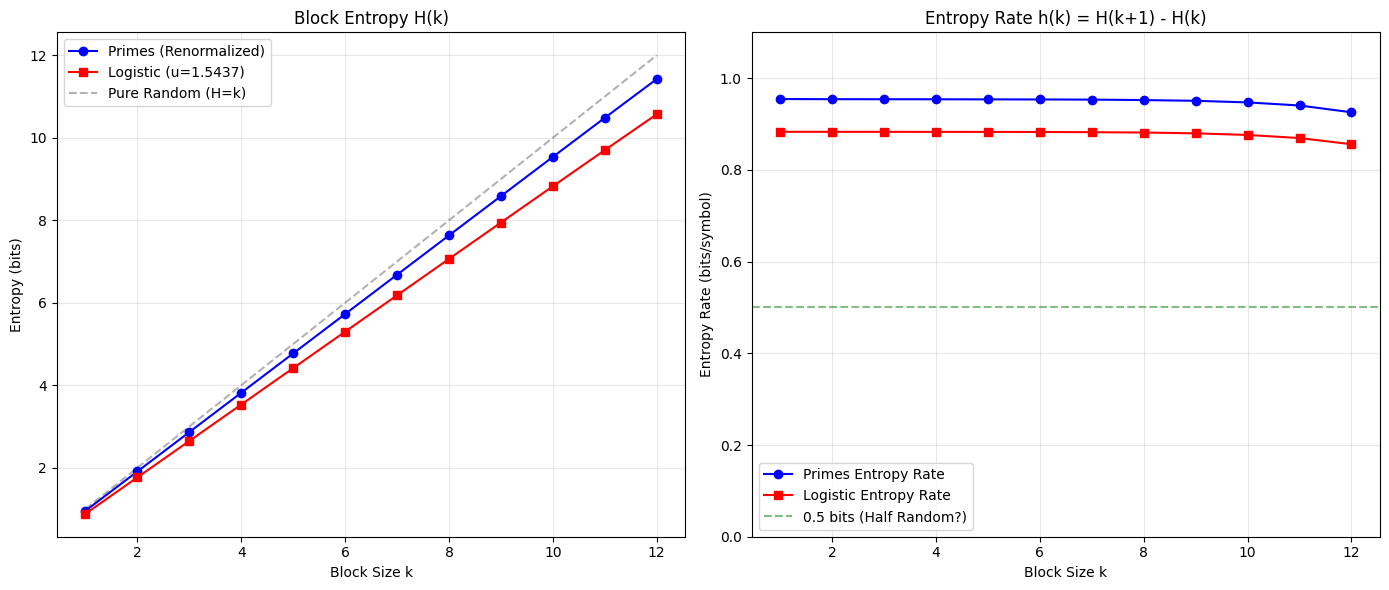


结果解读：
1. 观察 H(k) 的增长斜率。如果两者重合，说明它们携带信息的'密度'是一致的。
2. 观察 h(k) 的收敛值。随着 k 增大，h(k) 会趋向于系统的真实柯尔莫哥洛夫-西奈熵 (KS Entropy)。
   - 如果 h(k) 趋向于 1，说明是完全随机噪声。
   - 如果 h(k) 趋向于 0，说明是周期系统。
   - 如果 h(k) 稳定在 0 和 1 之间（例如 0.4 - 0.6），则有力证明了两者都是'确定性混沌'系统。
3. 如果红线(Logistic)和蓝线(Prime)在走势上高度贴合，这是两者具有相同动力学复杂度的强有力证据。


In [5]:
main()